<a href="https://colab.research.google.com/github/Jamiul-kawsar/ML_Breast_Cancer/blob/main/Basic_ML_breast_cancer.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt


In [ ]:
# dataset load
dataset = pd.read_csv('/content/data.csv')
dataset.head()

,id,diagnosis,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave points_mean,...,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave points_worst,symmetry_worst,fractal_dimension_worst,Unnamed: 32
0,842302,M,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,...,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890,NaN
1,842517,M,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,...,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902,NaN
2,84300903,M,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,...,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758,NaN
3,84348301,M,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,...,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300,NaN
4,84358402,M,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,...,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678,NaN


In [ ]:
features = dataset.drop(['id', 'diagnosis', 'Unnamed: 32'], axis = 1,errors= 'ignore')

In [ ]:
features.columns


Index(['radius_mean', 'texture_mean', 'perimeter_mean', 'area_mean',
       'smoothness_mean', 'compactness_mean', 'concavity_mean',
       'concave points_mean', 'symmetry_mean', 'fractal_dimension_mean',
       'radius_se', 'texture_se', 'perimeter_se', 'area_se', 'smoothness_se',
       'compactness_se', 'concavity_se', 'concave points_se', 'symmetry_se',
       'fractal_dimension_se', 'radius_worst', 'texture_worst',
       'perimeter_worst', 'area_worst', 'smoothness_worst',
       'compactness_worst', 'concavity_worst', 'concave points_worst',
       'symmetry_worst', 'fractal_dimension_worst'],
      dtype='object')

In [ ]:
target = dataset['diagnosis']
target

,diagnosis
0,M
1,M
2,M
3,M
4,M
...,...
564,M
565,M
566,M
567,M


In [ ]:
# label encoding of target data
from sklearn.preprocessing import LabelEncoder
le = LabelEncoder()
target = le.fit_transform(target)
target

array([1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 0, 0,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 1, 1, 1, 1, 1, 1,
       1, 1, 0, 1, 0, 0, 0, 0, 0, 1, 1, 0, 1, 1, 0, 0, 0, 0, 1, 0, 1, 1,
       0, 0, 0, 0, 1, 0, 1, 1, 0, 1, 0, 1, 1, 0, 0, 0, 1, 1, 0, 1, 1, 1,
       0, 0, 0, 1, 0, 0, 1, 1, 0, 0, 0, 1, 1, 0, 0, 0, 0, 1, 0, 0, 1, 0,
       0, 0, 0, 0, 0, 0, 0, 1, 1, 1, 0, 1, 1, 0, 0, 0, 1, 1, 0, 1, 0, 1,
       1, 0, 1, 1, 0, 0, 1, 0, 0, 1, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 1, 0, 0, 0, 0, 1, 1, 0, 1, 0, 0, 1, 1, 0, 0, 1, 1, 0, 0, 0,
       0, 1, 0, 0, 1, 1, 1, 0, 1, 0, 1, 0, 0, 0, 1, 0, 0, 1, 1, 0, 1, 1,
       1, 1, 0, 1, 1, 1, 0, 1, 0, 1, 0, 0, 1, 0, 1, 1, 1, 1, 0, 0, 1, 1,
       0, 0, 0, 1, 0, 0, 0, 0, 0, 1, 1, 0, 0, 1, 0, 0, 1, 1, 0, 1, 0, 0,
       0, 0, 1, 0, 0, 0, 0, 0, 1, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 0, 0, 0, 0, 0, 0, 1, 0, 1, 0, 0, 1, 0, 0, 1, 0, 1, 1, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 1,

In [ ]:
target.shape

(569,)

In [ ]:
# train test split
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(features, target, test_size= 0.2, random_state=42, stratify = target)

print("shape of X train : ", X_train.shape)
print("shape of X test : ", X_test.shape)
print("shape of y train : ", y_train.shape)
print("shape of y test : ", y_test.shape)

shape of X train :  (455, 30)
shape of X test :  (114, 30)
shape of y train :  (455,)
shape of y test :  (114,)


In [ ]:
# scalling
from sklearn.preprocessing import MinMaxScaler
scaler = MinMaxScaler()
# scale
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)
# reconvert back to dataframe
X_train = pd.DataFrame(X_train_scaled, columns=X_train.columns)
X_test = pd.DataFrame(X_test_scaled, columns=X_test.columns)

X_train.head()

,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave points_mean,symmetry_mean,fractal_dimension_mean,...,radius_worst,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave points_worst,symmetry_worst,fractal_dimension_worst
0,0.427801,0.457558,0.407090,0.277540,0.193775,0.145114,0.077296,0.165159,0.236364,0.142585,...,0.400569,0.582623,0.365506,0.237122,0.309912,0.124002,0.116534,0.342784,0.272620,0.193362
1,0.252686,0.090632,0.242278,0.135992,0.399346,0.154684,0.093416,0.183897,0.454040,0.197246,...,0.198150,0.096482,0.182081,0.089437,0.444628,0.096351,0.099201,0.322715,0.248768,0.083104
2,0.277770,0.394319,0.268399,0.157370,0.128853,0.195632,0.143533,0.092793,0.262626,0.230932,...,0.230167,0.399520,0.205289,0.113203,0.150895,0.161355,0.146805,0.192474,0.181944,0.173619
3,0.374793,0.433548,0.402944,0.229692,0.366340,0.623029,0.640347,0.482654,0.495455,0.397034,...,0.299538,0.414446,0.373475,0.159138,0.467080,0.661398,0.720367,0.850515,0.256456,0.396563
4,0.550381,0.356442,0.541151,0.403181,0.316087,0.267530,0.349110,0.384245,0.321717,0.143008,...,0.475987,0.406183,0.445690,0.299302,0.413590,0.178916,0.275240,0.512027,0.152967,0.125738


In [ ]:
X_test.head()

,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave points_mean,symmetry_mean,fractal_dimension_mean,...,radius_worst,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave points_worst,symmetry_worst,fractal_dimension_worst
0,0.209617,0.037538,0.204202,0.110201,0.309446,0.145605,0.082287,0.130368,0.306566,0.230720,...,0.173959,0.105277,0.165994,0.079950,0.552268,0.205402,0.167891,0.307835,0.286024,0.198019
1,0.660656,0.468380,0.657246,0.517709,0.378531,0.433164,0.635426,0.651093,0.578283,0.185169,...,0.627890,0.399254,0.572190,0.448486,0.329723,0.281272,0.558387,0.723368,0.307707,0.153811
2,0.434900,0.215083,0.431967,0.273595,0.359699,0.381633,0.155834,0.268241,0.469697,0.327966,...,0.321594,0.189765,0.312217,0.166216,0.345572,0.220925,0.168850,0.429897,0.313030,0.226682
3,0.352075,0.340210,0.350287,0.211665,0.347012,0.290534,0.219963,0.290209,0.413636,0.289407,...,0.298826,0.502132,0.294288,0.157589,0.475005,0.267107,0.255112,0.537801,0.227282,0.252460
4,0.302854,0.710517,0.294036,0.175483,0.296759,0.168333,0.066050,0.162227,0.159091,0.210169,...,0.253291,0.788646,0.230490,0.127900,0.303969,0.111389,0.055935,0.266770,0.124384,0.142398


**KNN**

In [ ]:
# knn
from sklearn.neighbors import KNeighborsClassifier
knn = KNeighborsClassifier(n_neighbors=5)
knn.fit(X_train, y_train)

KNeighborsClassifier()

In [ ]:
# evaluation
predict = knn.predict(X_test)
# classification report
score = knn.score(X_test, y_test)
print("Accuracy: ", score)
from sklearn.metrics import classification_report
print(classification_report(y_test, predict))


Accuracy:  0.956140350877193
              precision    recall  f1-score   support

           0       0.95      0.99      0.97        72
           1       0.97      0.90      0.94        42

    accuracy                           0.96       114
   macro avg       0.96      0.95      0.95       114
weighted avg       0.96      0.96      0.96       114



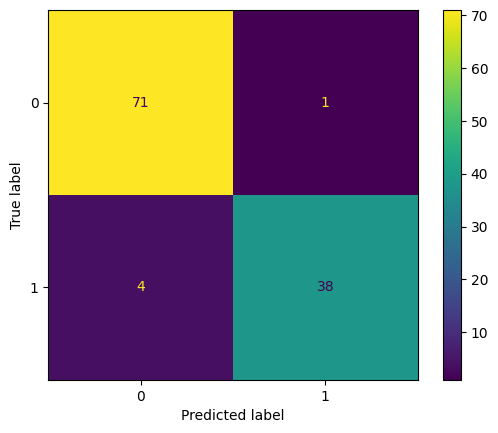

In [ ]:
# confusion matric
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

cm = confusion_matrix(y_test, predict)
ConfusionMatrixDisplay(confusion_matrix=cm).plot()
plt.show()


**Naive Bayes**

In [ ]:
# naive bayes
from sklearn.naive_bayes import GaussianNB
nb = GaussianNB()
nb.fit(X_train, y_train)

GaussianNB()

In [ ]:
# evaluation
predict = nb.predict(X_test)
# classification report
score = nb.score(X_test, y_test)
print("Accuracy: ", score)
from sklearn.metrics import classification_report
print(classification_report(y_test, predict))

Accuracy:  0.9210526315789473
              precision    recall  f1-score   support

           0       0.92      0.96      0.94        72
           1       0.92      0.86      0.89        42

    accuracy                           0.92       114
   macro avg       0.92      0.91      0.91       114
weighted avg       0.92      0.92      0.92       114



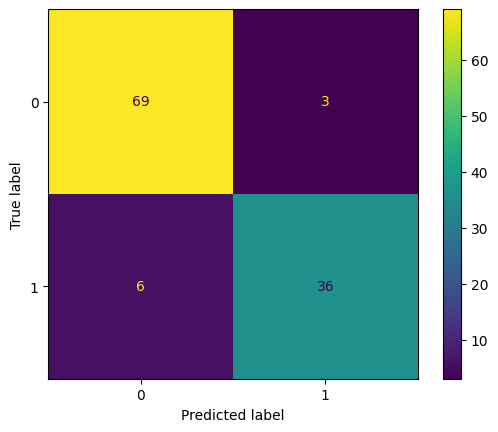

In [ ]:
# confusion matric
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

cm = confusion_matrix(y_test, predict)
ConfusionMatrixDisplay(confusion_matrix=cm).plot()
plt.show()

**Logistic Regression**

In [ ]:
# logistic Regression
from sklearn.linear_model import LogisticRegression
lr = LogisticRegression(max_iter=1000, random_state=42)
lr.fit(X_train, y_train)

LogisticRegression(max_iter=1000, random_state=42)

In [ ]:
# evaluation
predict = lr.predict(X_test)
# classification report
score = lr.score(X_test, y_test)
print("Accuracy: ", score)
from sklearn.metrics import classification_report
print(classification_report(y_test, predict))

Accuracy:  0.9736842105263158
              precision    recall  f1-score   support

           0       0.96      1.00      0.98        72
           1       1.00      0.93      0.96        42

    accuracy                           0.97       114
   macro avg       0.98      0.96      0.97       114
weighted avg       0.97      0.97      0.97       114



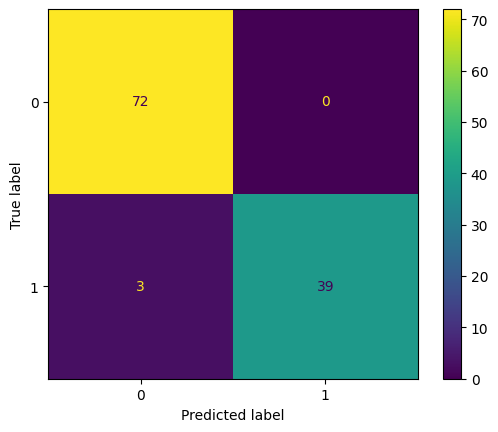

In [ ]:
# confusion matric
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

cm = confusion_matrix(y_test, predict)
ConfusionMatrixDisplay(confusion_matrix=cm).plot()
plt.show()

**Support Vector Machine**

In [ ]:
# svm
from sklearn.svm import SVC
svm = SVC(kernel='linear', random_state=42)
svm.fit(X_train, y_train)

SVC(kernel='linear', random_state=42)

In [ ]:
# evaluation
predict = svm.predict(X_test)
# classification report
score = svm.score(X_test, y_test)
print("Accuracy: ", score)
from sklearn.metrics import classification_report
print(classification_report(y_test, predict))

Accuracy:  0.9824561403508771
              precision    recall  f1-score   support

           0       0.97      1.00      0.99        72
           1       1.00      0.95      0.98        42

    accuracy                           0.98       114
   macro avg       0.99      0.98      0.98       114
weighted avg       0.98      0.98      0.98       114



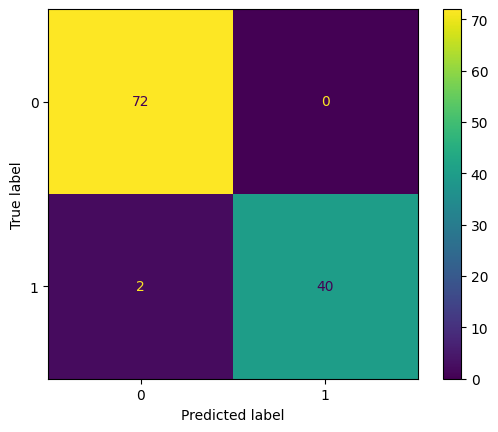

In [ ]:
# confusion matric
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

cm = confusion_matrix(y_test, predict)
ConfusionMatrixDisplay(confusion_matrix=cm).plot()
plt.show()

**Comparision between all models**

In [ ]:
# compare all models
from sklearn.metrics import accuracy_score
accuracy = []
models = [knn, nb, lr, svm]
model_names = ['KNN', 'Naive Bayes', 'Logistic Regression', 'SVM']
for model, name in zip(models, model_names):
    y_pred = model.predict(X_test)
    accuracy.append(round(accuracy_score(y_test, y_pred),2))

print(accuracy)

[0.96, 0.92, 0.97, 0.98]


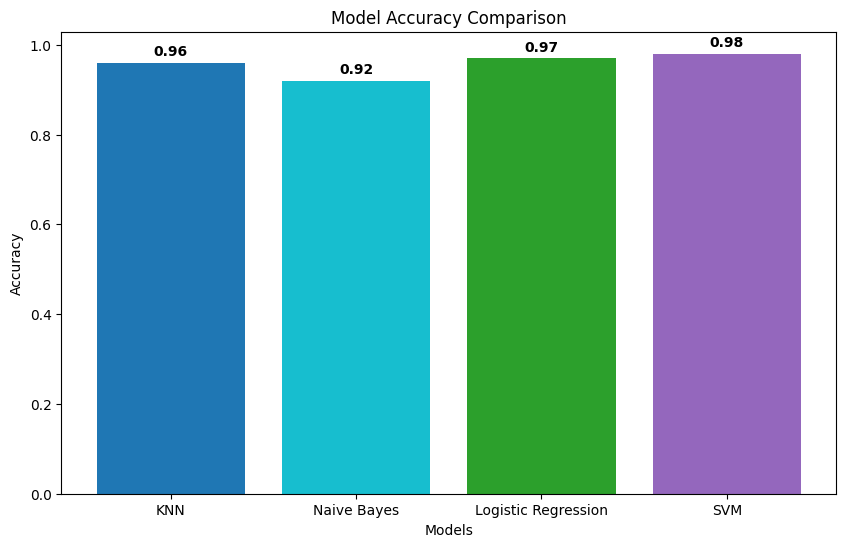

In [ ]:
# chart the model and score using plt
# different color in bar and show the percentage into bar
plt.figure(figsize=(10, 6))
bars = plt.bar(model_names, accuracy, color=['#1f77b4', '#17becf', '#2ca02c', '#9467bd'])
plt.xlabel('Models')
plt.ylabel('Accuracy')
plt.title('Model Accuracy Comparison')
plt.bar_label(bars, padding=3, fontweight='bold')
plt.show()


In [ ]:
# Hyperparameter Tuning (GridSearchCV) with svm
param_grid = {
    'C': [0.1, 1, 10, 100],
    'gamma': ['scale', 'auto', 0.01, 0.001],
    'kernel': ['rbf', 'linear']
}

In [ ]:
from sklearn.model_selection import GridSearchCV
grid_search = GridSearchCV(
    estimator = SVC(random_state=42),
    param_grid = param_grid,
    scoring = 'accuracy',
    cv = 5,
    n_jobs = -1,
    verbose = 1
)

grid_search.fit(X_train, y_train)

Fitting 5 folds for each of 32 candidates, totalling 160 fits


GridSearchCV(cv=5, estimator=SVC(random_state=42), n_jobs=-1,
             param_grid={'C': [0.1, 1, 10, 100],
                         'gamma': ['scale', 'auto', 0.01, 0.001],
                         'kernel': ['rbf', 'linear']},
             scoring='accuracy', verbose=1)

In [ ]:
print(f"Best Parameters Found: {grid_search.best_params_}")
print(f"Cross-Validation Best Accuracy Score: {grid_search.best_score_ * 100:.2f}%")

Best Parameters Found: {'C': 10, 'gamma': 'scale', 'kernel': 'rbf'}
Cross-Validation Best Accuracy Score: 97.58%


In [ ]:
best_svm_model = grid_search.best_estimator_
predictions = best_svm_model.predict(X_test)

In [ ]:
print(classification_report(y_test, predictions))

              precision    recall  f1-score   support

           0       0.96      1.00      0.98        72
           1       1.00      0.93      0.96        42

    accuracy                           0.97       114
   macro avg       0.98      0.96      0.97       114
weighted avg       0.97      0.97      0.97       114



**Save the SVM model**

In [ ]:
import joblib

# 1. Define the file names for export
model_filename = 'breast_cancer_svm_model.pkl'
scaler_filename = 'breast_cancer_scaler.pkl'

# 2. Save the trained model and scaler to disk
# Replaces 'best_svm_model' or 'svm_model' with whatever variable holds your final trained SVM
joblib.dump(best_svm_model, model_filename)
joblib.dump(scaler, scaler_filename)

print("=" * 50)
print(f"🎉 Success! Files saved to your environment:")
print(f"👉 Model File  : {model_filename}")
print(f"👉 Scaler File : {scaler_filename}")
print("=" * 50)


🎉 Success! Files saved to your environment:
👉 Model File  : breast_cancer_svm_model.pkl
👉 Scaler File : breast_cancer_scaler.pkl
